# FMCW Radar Simulation — Python Notebook

This notebook mirrors the MATLAB Live Script, step-by-step:
- Define radar and chirp parameters
- Generate FMCW transmit signal
- Simulate received signals across chirps and antenna array
- Perform range, Doppler, and angle FFTs
- Visualize Range, Range–Doppler, and Range–Angle
- Build a 3D radar cube point cloud
- Detect strongest peaks and compare with ground truth


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift


def nextpow2(n: int) -> int:
    return 1 if n == 0 else int(2 ** np.ceil(np.log2(n)))


def awgn_measured(x: np.ndarray, snr_db: float) -> np.ndarray:
    """Match MATLAB awgn(x, SNR, 'measured'): add complex Gaussian noise
    to achieve the requested SNR relative to the measured signal power.
    """
    power = np.mean(np.abs(x) ** 2)
    noise_power = power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (
        np.random.normal(size=x.shape) + 1j * np.random.normal(size=x.shape)
    )
    return x + noise


## Parameters
Set physical constants, chirp timing, frame setup, antenna geometry, and target list.


In [2]:
c = 3e8
fc = 77e9
lambda_c = c / fc

# Chirp parameters
bw = 150e6
T_chirp = 10e-6
k = bw / T_chirp
fs = 2 * bw

# Frame parameters
n_chirps = 64
T_frame = T_chirp * n_chirps  # parity with MATLAB

# Antenna array
N_rx = 16
d = lambda_c / 2

# Targets (same as MATLAB)
target_range = np.array([200, 75, 50], dtype=float)
target_vel = np.array([20, -15, 10], dtype=float)
target_rcs = np.array([10, 0.8, 0.5], dtype=float)
target_angle = np.deg2rad(np.array([30, -20, 10], dtype=float))
n_targets = target_range.size


## Transmit waveform
Create the FMCW chirp for one sweep: phase = 2π(fc t + ½ k t²), Tx = e^{j phase}.


In [3]:
t = np.arange(0, T_chirp, 1 / fs)
n_samples = t.size
tx_phase = 2 * np.pi * (fc * t + 0.5 * k * t ** 2)
Tx = np.exp(1j * tx_phase)


## Received signal simulation
For each chirp and target, apply time delay τ = 2R/c, phase rotation for array element m, and sum across targets. Add AWGN with 10 dB SNR measured relative to the signal power. Then mix with Tx.


In [4]:
Mix_matrix = np.zeros((n_chirps, n_samples, N_rx), dtype=np.complex128)

for i in range(n_chirps):
    Rx_total = np.zeros((N_rx, n_samples), dtype=np.complex128)
    time_at_chirp_start = i * T_chirp

    for j in range(n_targets):
        r0 = target_range[j]
        v0 = target_vel[j]
        theta = target_angle[j]

        current_range = r0 + v0 * time_at_chirp_start
        tau = 2 * current_range / c
        t_rx = t - tau

        rx_phase = 2 * np.pi * (fc * t_rx + 0.5 * k * t_rx ** 2)
        Rx_j = np.exp(1j * rx_phase)

        for m in range(N_rx):
            Rx_total[m, :] += (target_rcs[j] / (current_range ** 4)) * Rx_j * np.exp(
                -1j * 2 * np.pi * m * d * np.sin(theta) / lambda_c
            )

    Rx_noisy = awgn_measured(Rx_total.T, 10)
    Mix_matrix[i, :, :] = (Tx[:, None] * np.conj(Rx_noisy)).reshape(n_samples, N_rx)


## Plot: Raw ADC samples
Visualize real part of mixed signal for the first antenna across chirps and fast-time samples.


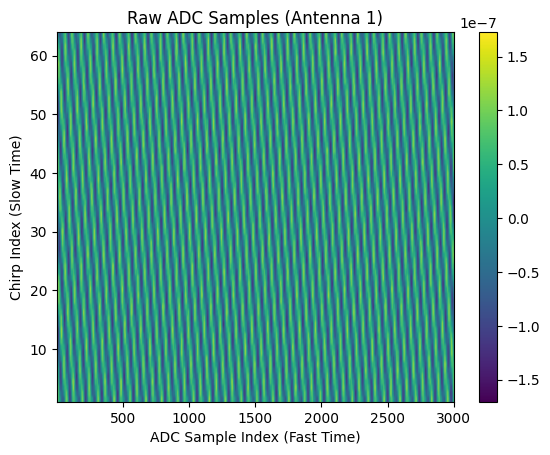

In [5]:
plt.figure()
plt.imshow(
    np.real(Mix_matrix[:, :, 0]),
    aspect="auto",
    extent=[1, n_samples, 1, n_chirps],
    origin="lower",
)
plt.title("Raw ADC Samples (Antenna 1)")
plt.xlabel("ADC Sample Index (Fast Time)")
plt.ylabel("Chirp Index (Slow Time)")
plt.colorbar()
plt.show()


## Range FFT
FFT along fast-time for each chirp and antenna. The range axis uses f_r = (fs * k / n_fft) and R = f_r * c / (2k).


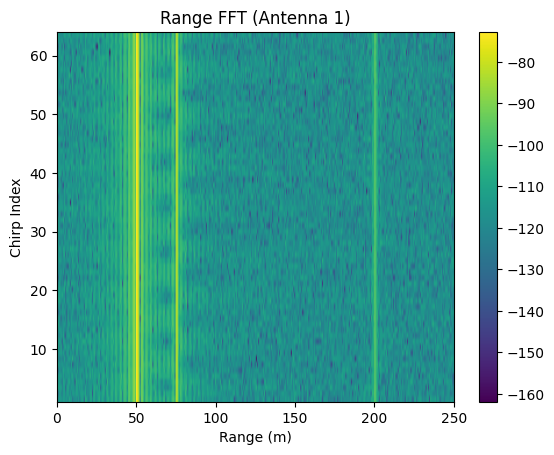

In [6]:
n_fft_range = nextpow2(n_samples)
range_fft = fft(Mix_matrix, n_fft_range, axis=1)
range_axis = (fs * np.arange(n_fft_range) / n_fft_range) * c / (2 * k)

plt.figure()
range_plot = np.abs(range_fft[:, : n_fft_range // 2 + 1, 0])
plt.imshow(
    20 * np.log10(range_plot + 1e-12),
    aspect="auto",
    extent=[range_axis[0], range_axis[n_fft_range // 2], 1, n_chirps],
    origin="lower",
)
plt.title("Range FFT (Antenna 1)")
plt.xlabel("Range (m)")
plt.ylabel("Chirp Index")
plt.colorbar()
plt.xlim([0, 250])
plt.show()


## Doppler FFT
FFT along slow-time (chirp index), centered with fftshift. Convert Doppler frequency to velocity via v = f_d * λ / 2.


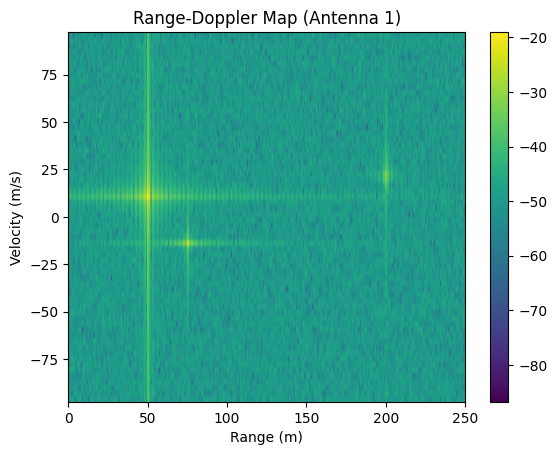

In [7]:
n_fft_vel = nextpow2(n_chirps)
rdm = fftshift(fft(range_fft, n_fft_vel, axis=0), axes=0)
fs_doppler = 1 / T_chirp
doppler_freq_axis = np.linspace(-fs_doppler / 2, fs_doppler / 2, n_fft_vel)
vel_axis = doppler_freq_axis * lambda_c / 2

plt.figure()
rdm_plot = np.abs(rdm[:, : n_fft_range // 2 + 1, 0])
plt.imshow(
    10 * np.log10(rdm_plot + 1e-12),
    aspect="auto",
    extent=[range_axis[0], range_axis[n_fft_range // 2], vel_axis[0], vel_axis[-1]],
    origin="lower",
)
plt.title("Range-Doppler Map (Antenna 1)")
plt.xlabel("Range (m)")
plt.ylabel("Velocity (m/s)")
plt.colorbar()
plt.xlim([0, 250])
plt.show()


## Angle FFT
FFT across the antenna array (ULA) and center with fftshift. Map spatial frequency to angle using θ = asin(u), u in [−1, 1].


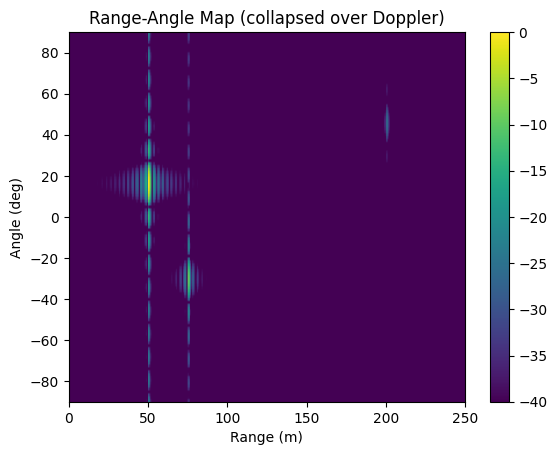

In [8]:
n_fft_angle = 128
RDA_fft = fftshift(fft(rdm, n_fft_angle, axis=2), axes=2)
angle_axis = np.degrees(np.arcsin(np.linspace(-1, 1, n_fft_angle)))

angle_map_all = np.max(np.abs(RDA_fft[:, : n_fft_range // 2 + 1, :]), axis=0)
angle_map_dB = 20 * np.log10(angle_map_all / (np.max(angle_map_all) + 1e-12) + 1e-12)
angle_map_dB[angle_map_dB < -40] = -40

plt.figure()
plt.imshow(
    angle_map_dB.T,
    aspect="auto",
    extent=[range_axis[0], range_axis[n_fft_range // 2], angle_axis[0], angle_axis[-1]],
    origin="lower",
)
plt.xlabel("Range (m)")
plt.ylabel("Angle (deg)")
plt.title("Range-Angle Map (collapsed over Doppler)")
plt.colorbar()
plt.xlim([0, 250])
plt.show()


## 3D Radar Cube point cloud
Normalize magnitudes, threshold, and scatter in (range, velocity, angle) with color = amplitude.


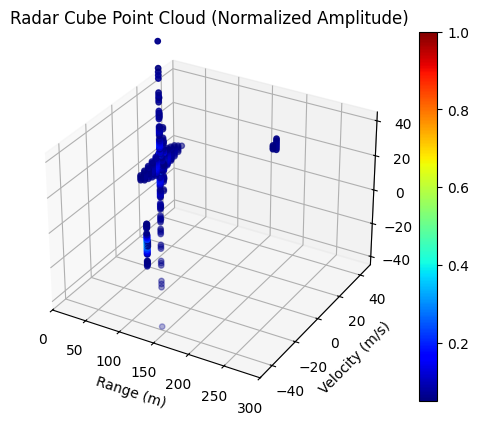

In [9]:
cube_data = np.abs(RDA_fft[:, : n_fft_range // 2 + 1, :])
cube_data = cube_data / (np.max(cube_data) + 1e-12)
min_thresh = 0.05
mask = cube_data > min_thresh

# Build grids from previously computed axes
vel_grid, range_grid, angle_grid = np.meshgrid(
    vel_axis,
    range_axis[: n_fft_range // 2 + 1],
    angle_axis,
    indexing="ij",
)

x = range_grid[mask]
y = vel_grid[mask]
z = angle_grid[mask]
v = cube_data[mask]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(x, y, z, c=v, s=15, cmap="jet")
ax.set_xlabel("Range (m)")
ax.set_ylabel("Velocity (m/s)")
ax.set_zlabel("Angle (deg)")
ax.set_title("Radar Cube Point Cloud (Normalized Amplitude)")
fig.colorbar(sc)
ax.set_xlim([0, 300])
ax.set_ylim([-50, 50])
ax.set_zlim([-45, 45])
plt.show()


## Detection and comparison
Threshold normalized magnitude, take top-N detections (N = number of targets), and print a side-by-side comparison against the ground truth.


In [10]:
cube_mag = np.abs(RDA_fft[:, : n_fft_range // 2 + 1, :])
cube_mag = cube_mag / (np.max(cube_mag) + 1e-12)

detection_thresh = 0.1
det_indices = np.argwhere(cube_mag >= detection_thresh)
det_amplitudes = cube_mag[cube_mag >= detection_thresh]

N_peaks = min(n_targets, det_amplitudes.size)
if N_peaks > 0:
    sort_idx = np.argsort(det_amplitudes)[::-1][:N_peaks]
    sel = det_indices[sort_idx]
    vel_idx = sel[:, 0]
    range_idx = sel[:, 1]
    angle_idx = sel[:, 2]

    det_ranges = range_axis[range_idx]
    det_velocities = vel_axis[vel_idx]
    det_angles = angle_axis[angle_idx]

    ActualRange = target_range[:N_peaks]
    ActualVelocity = target_vel[:N_peaks]
    ActualAngle = np.degrees(target_angle[:N_peaks])

    print("Detected Targets vs Actual:")
    header = (
        "MeasuredRange(m)",
        "ActualRange(m)",
        "MeasuredVelocity(m/s)",
        "ActualVelocity(m/s)",
        "MeasuredAngle(deg)",
        "ActualAngle(deg)",
        "NormalizedAmplitude",
    )
    print("\t".join(header))
    for i in range(N_peaks):
        print(
            f"{det_ranges[i]:.2f}\t{ActualRange[i]:.2f}\t"
            f"{det_velocities[i]:.2f}\t{ActualVelocity[i]:.2f}\t"
            f"{det_angles[i]:.2f}\t{ActualAngle[i]:.2f}\t{det_amplitudes[sort_idx[i]]:.3f}"
        )
else:
    print("No detections above threshold.")


Detected Targets vs Actual:
MeasuredRange(m)	ActualRange(m)	MeasuredVelocity(m/s)	ActualVelocity(m/s)	MeasuredAngle(deg)	ActualAngle(deg)	NormalizedAmplitude
49.80	200.00	10.82	20.00	10.43	30.00	1.000
49.80	75.00	10.82	-15.00	11.35	-20.00	0.980
49.80	50.00	10.82	10.00	9.52	10.00	0.969
